# Notebook 1: Quantitative Portfolio Optimization

This notebook introduces mathematical modeling for portfolio optimization. We'll cover:

1. **Investment Narratives to Mathematical Problems** - Translating human goals to optimization tasks
2. **Mean-Variance Optimization** - Classic Markowitz approach with different targets
3. **Hierarchical Risk Parity (HRP)** - Modern clustering-based approach
4. **Evaluation Metrics** - Backtest metrics vs. mathematical toolkit metrics

Key insight: Mathematical modeling requires expert translation from customer narrative to optimization problem.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from portfolio_optimizer import (
    PortfolioConfig,
    download_market_data,
    calculate_returns,
    optimize_portfolio,
    optimize_hrp,
    plot_efficient_frontier,
    plot_hrp_dendrogram,
    plot_weights_comparison,
    backtest_portfolio,
    plot_backtest,
    get_universe,
    UNIVERSE_DEFINITIONS
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

print("Setup complete!")

Setup complete!


## 1. Investment Narratives - Customer Stories

Real wealth management starts with customer narratives. Here are example scenarios that a financial advisor might receive:

In [2]:
import json

# Load customer scenarios from external JSON file
with open('scenarios.json', 'r') as f:
    scenarios_data = json.load(f)

CUSTOMER_SCENARIOS = scenarios_data['personas']
CONFIG = scenarios_data['config']

# Display scenarios
for scenario_id, scenario in CUSTOMER_SCENARIOS.items():
    print(f"\n{'='*60}")
    print(f"Customer: {scenario['name']} ({scenario_id.upper()})")
    print(f"{'='*60}")
    print(f"\nNarrative: {scenario['narrative'][:200]}...")
    print(f"\nExpert Translation:")
    for key, value in scenario['expert_translation'].items():
        print(f"  - {key}: {value}")


Customer: Sarah Chen (SARAH_CONSERVATIVE)

Narrative: I'm Sarah, 58 years old, and planning to retire in 7 years. I have $500,000 saved and want stable income with capital preservation. I can't afford to lose more than 15% of my portfolio. I prefer US-ba...

Expert Translation:
  - optimization_target: min_volatility
  - universe: conservative
  - time_horizon_years: 7
  - max_drawdown_tolerance: 0.15
  - risk_tolerance: low
  - investment_amount: 500000
  - geographic_preference: US only
  - allow_short: False

Customer: Marcus Johnson (MARCUS_GROWTH)

Narrative: I'm Marcus, 28 years old, just started my career as a software engineer. I have $50,000 to invest and want to maximize long-term growth. I can tolerate high volatility since I won't need this money fo...

Expert Translation:
  - optimization_target: max_sharpe
  - universe: us_tech
  - time_horizon_years: 30
  - max_drawdown_tolerance: 0.4
  - risk_tolerance: high
  - investment_amount: 50000
  - geographic_preference: US te

## 2. Data Download and Exploration

We'll download historical market data for our analysis.

In [3]:
# Define analysis period
START_DATE = "2019-01-01"
END_DATE = "2024-01-01"

# Download data for different universes
print("Downloading market data...")

data_cache = {}
for universe_name in ['us_tech', 'conservative', 'global_diversified']:
    tickers = get_universe(universe_name)
    prices = download_market_data(tickers, START_DATE, END_DATE)
    data_cache[universe_name] = prices
    print(f"  {universe_name}: {len(prices.columns)} tickers, {len(prices)} days")

print("\nData download complete!")

  us_tech: 15 tickers, 1258 days


  conservative: 8 tickers, 1258 days


  global_diversified: 15 tickers, 1258 days

Data download complete!


In [4]:
# Show sample data
sample_prices = data_cache['us_tech']
print("US Tech Universe - Sample Prices:")
display(sample_prices.tail())

# Calculate and display returns statistics
returns = calculate_returns(sample_prices)
print("\nAnnualized Statistics:")
stats = pd.DataFrame({
    'Mean Return (%)': returns.mean() * 252 * 100,
    'Volatility (%)': returns.std() * np.sqrt(252) * 100,
    'Sharpe Ratio': (returns.mean() * 252) / (returns.std() * np.sqrt(252))
}).round(2)
display(stats.sort_values('Sharpe Ratio', ascending=False))

US Tech Universe - Sample Prices:


Ticker,AAPL,ADBE,AMD,AMZN,CRM,CSCO,GOOG,IBM,INTC,META,MSFT,NVDA,ORCL,QCOM,TSLA
Date,,,,,,,,,,,,,,,
2023-12-22,191.7888,598.7500,139.6000,153.4200,263.1427,47.0397,141.6575,152.5418,47.3656,350.9386,369.0771,48.8028,103.6098,137.6341,252.5400
2023-12-26,191.2439,598.2600,143.4100,153.4100,263.0242,47.2181,141.7568,153.5485,49.8326,352.3686,369.1560,49.2516,103.6001,139.5238,256.6100
2023-12-27,191.3430,596.0800,146.0700,153.3400,263.5182,47.3684,140.3871,153.7837,50.0892,355.3477,368.5746,49.3895,103.3562,139.7732,261.4400
2023-12-28,191.7690,595.5200,148.7600,153.3800,262.3918,47.4059,140.2283,154.0565,49.7241,355.8343,369.7668,49.4944,103.6586,139.9074,253.1800
2023-12-29,190.7288,596.6000,147.4100,151.9400,259.9812,47.4435,139.8809,153.8684,49.5859,351.5046,370.5157,49.4944,102.8586,138.7276,248.4800



Annualized Statistics:


,Mean Return (%),Volatility (%),Sharpe Ratio
Ticker,,,
NVDA,67.1800,51.7700,1.3000
AAPL,37.8000,32.2300,1.1700
TSLA,70.8100,64.7000,1.0900
MSFT,32.0300,30.4900,1.0500
AMD,55.5600,53.6900,1.0300
GOOG,24.9500,31.8200,0.7800
ORCL,23.3200,30.7800,0.7600
ADBE,26.4200,36.8200,0.7200
QCOM,29.7300,41.7800,0.7100


## 3. Mean-Variance Optimization: Three Different Targets

We'll demonstrate that different optimization targets yield different portfolios, even with the same universe.

In [5]:
# Use US Tech universe for demonstration
prices = data_cache['us_tech']

# Create three different optimization configurations
configs = {
    'Min Volatility': PortfolioConfig(
        tickers=list(prices.columns),
        start_date=START_DATE,
        end_date=END_DATE,
        optimization_target='min_volatility'
    ),
    'Max Sharpe': PortfolioConfig(
        tickers=list(prices.columns),
        start_date=START_DATE,
        end_date=END_DATE,
        optimization_target='max_sharpe'
    ),
    'Target Return (25%)': PortfolioConfig(
        tickers=list(prices.columns),
        start_date=START_DATE,
        end_date=END_DATE,
        optimization_target='efficient_return',
        target_return=0.25
    )
}

# Run optimizations
optimized_portfolios = {}
for name, config in configs.items():
    try:
        result = optimize_portfolio(config, prices)
        optimized_portfolios[name] = result
        print(f"\n{name}:")
        print(f"  Expected Return: {result['expected_return']*100:.2f}%")
        print(f"  Volatility: {result['volatility']*100:.2f}%")
        print(f"  Sharpe Ratio: {result['sharpe_ratio']:.3f}")
    except Exception as e:
        print(f"\n{name}: Failed - {e}")


Min Volatility:
  Expected Return: 14.45%
  Volatility: 22.35%
  Sharpe Ratio: 0.557

Max Sharpe:
  Expected Return: 59.77%
  Volatility: 41.08%
  Sharpe Ratio: 1.406

Target Return (25%):
  Expected Return: 25.00%
  Volatility: 23.52%
  Sharpe Ratio: 0.978


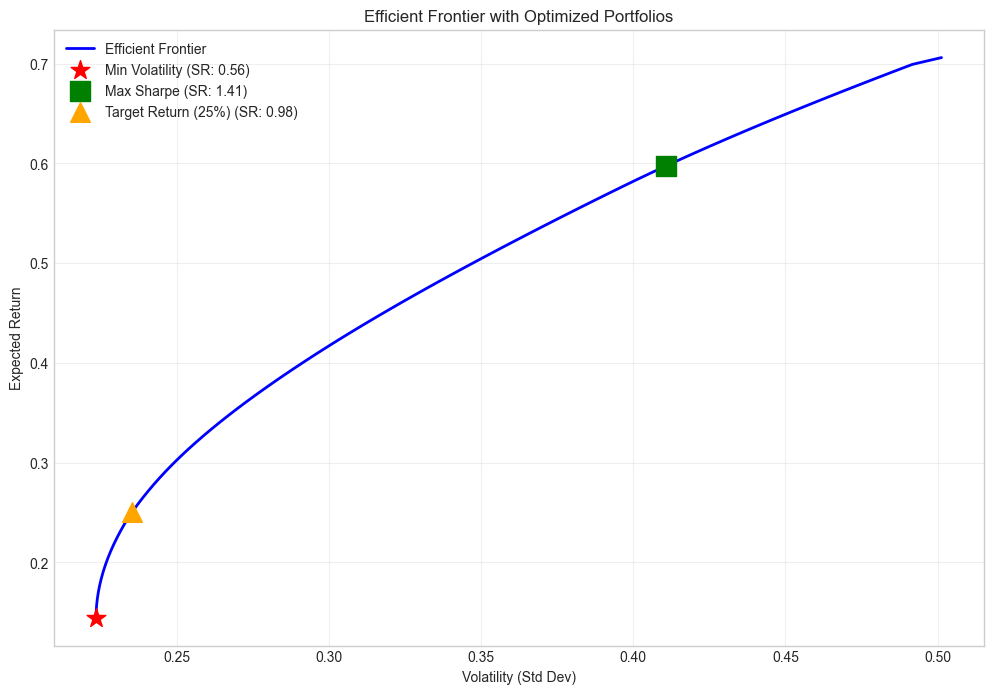

In [6]:
# Visualize efficient frontier with optimized portfolios
fig = plot_efficient_frontier(prices, optimized_portfolios)
plt.show()

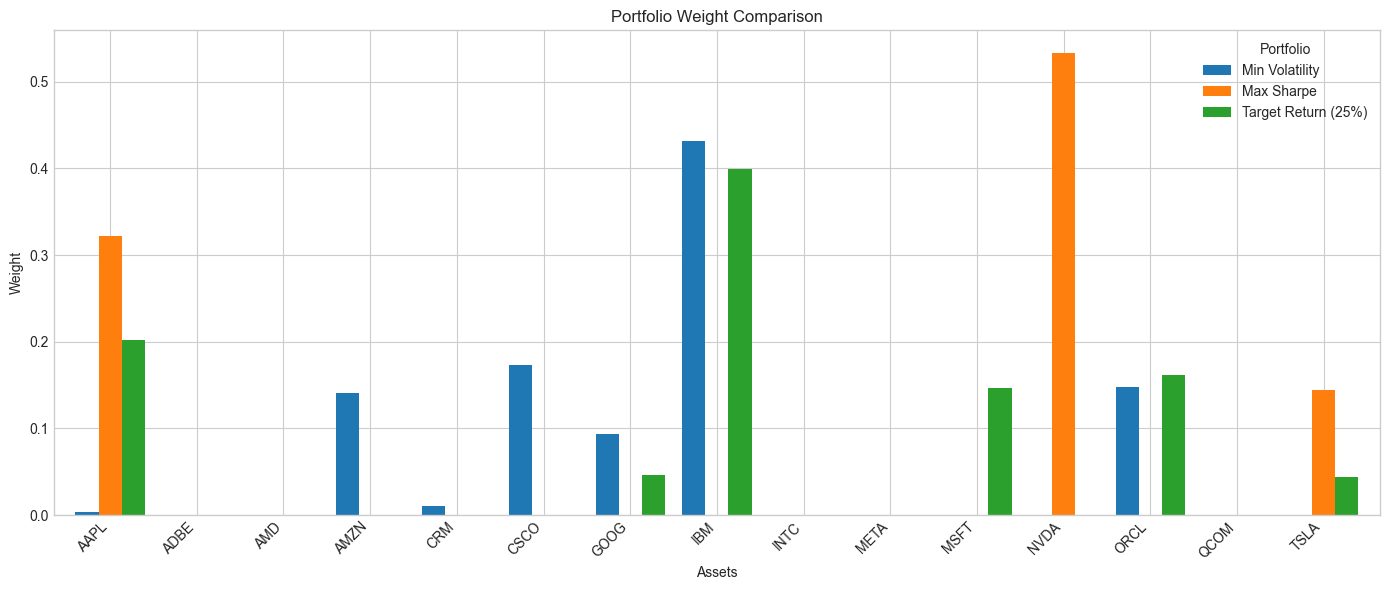

In [7]:
# Compare portfolio weights
fig = plot_weights_comparison(optimized_portfolios)
plt.show()

### Key Insight: Same Universe, Different Portfolios

Notice how the three portfolios have completely different allocations despite using the same asset universe. The optimization target fundamentally changes the resulting portfolio.

## 4. Applying Constraints from Customer Narrative

Real wealth management involves translating qualitative constraints into mathematical bounds.

In [8]:
# Apply constraints based on the "balanced_global" scenario
prices_global = data_cache['global_diversified']

# Without constraints
config_unconstrained = PortfolioConfig(
    tickers=list(prices_global.columns),
    start_date=START_DATE,
    end_date=END_DATE,
    optimization_target='max_sharpe'
)

# With max position constraint (15%)
config_constrained = PortfolioConfig(
    tickers=list(prices_global.columns),
    start_date=START_DATE,
    end_date=END_DATE,
    optimization_target='max_sharpe',
    max_position=0.15
)

result_unconstrained = optimize_portfolio(config_unconstrained, prices_global)
result_constrained = optimize_portfolio(config_constrained, prices_global)

print("Comparison: Unconstrained vs Max Position 15%")
print("="*50)
print(f"\nUnconstrained:")
print(f"  Sharpe: {result_unconstrained['sharpe_ratio']:.3f}")
print(f"  Max Weight: {max(result_unconstrained['weights'].values())*100:.1f}%")
print(f"  Non-zero positions: {sum(1 for w in result_unconstrained['weights'].values() if w > 0.01)}")

print(f"\nConstrained (max 15%):")
print(f"  Sharpe: {result_constrained['sharpe_ratio']:.3f}")
print(f"  Max Weight: {max(result_constrained['weights'].values())*100:.1f}%")
print(f"  Non-zero positions: {sum(1 for w in result_constrained['weights'].values() if w > 0.01)}")

Comparison: Unconstrained vs Max Position 15%

Unconstrained:
  Sharpe: 0.787
  Max Weight: 46.9%
  Non-zero positions: 3

Constrained (max 15%):
  Sharpe: 0.631
  Max Weight: 15.0%
  Non-zero positions: 8


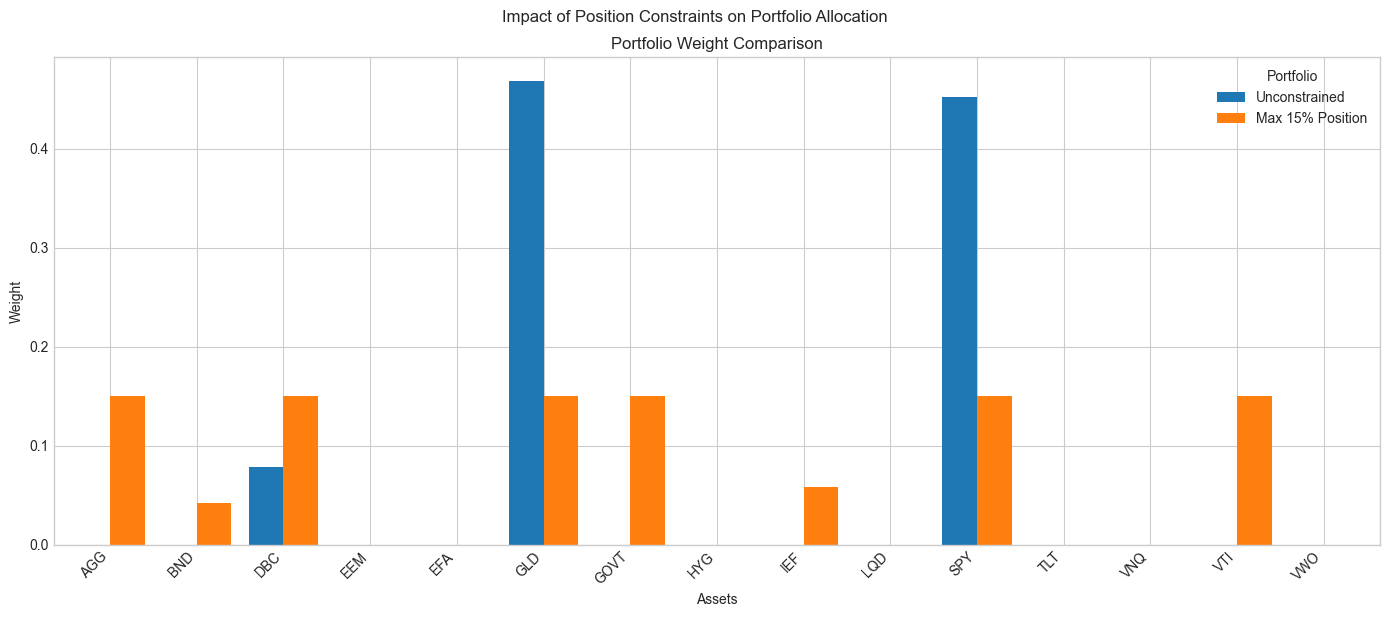

In [9]:
# Visualize constraint impact
comparison_portfolios = {
    'Unconstrained': result_unconstrained,
    'Max 15% Position': result_constrained
}
fig = plot_weights_comparison(comparison_portfolios)
plt.suptitle('Impact of Position Constraints on Portfolio Allocation', y=1.02)
plt.show()

## 5. Hierarchical Risk Parity (HRP)

HRP is a modern portfolio construction method that uses hierarchical clustering to build portfolios. Unlike mean-variance optimization, HRP doesn't require inverting the covariance matrix and is more robust to estimation errors.

In [10]:
# Run HRP optimization
hrp_result = optimize_hrp(prices, linkage_method='single')

print("Hierarchical Risk Parity Portfolio:")
print(f"  Expected Return: {hrp_result['expected_return']*100:.2f}%")
print(f"  Volatility: {hrp_result['volatility']*100:.2f}%")
print(f"  Sharpe Ratio: {hrp_result['sharpe_ratio']:.3f}")

# Show non-zero weights
print("\nPortfolio Weights (non-zero):")
for ticker, weight in sorted(hrp_result['weights'].items(), key=lambda x: -x[1]):
    if weight > 0.01:
        print(f"  {ticker}: {weight*100:.1f}%")

Hierarchical Risk Parity Portfolio:
  Expected Return: 25.84%
  Volatility: 25.14%
  Sharpe Ratio: 1.028

Portfolio Weights (non-zero):
  IBM: 17.7%
  ORCL: 12.9%
  CSCO: 10.6%
  MSFT: 6.5%
  GOOG: 6.3%
  AAPL: 6.1%
  AMZN: 6.0%
  INTC: 5.6%
  CRM: 5.1%
  QCOM: 4.9%
  META: 4.5%
  ADBE: 4.5%
  TSLA: 4.3%
  NVDA: 2.5%
  AMD: 2.3%


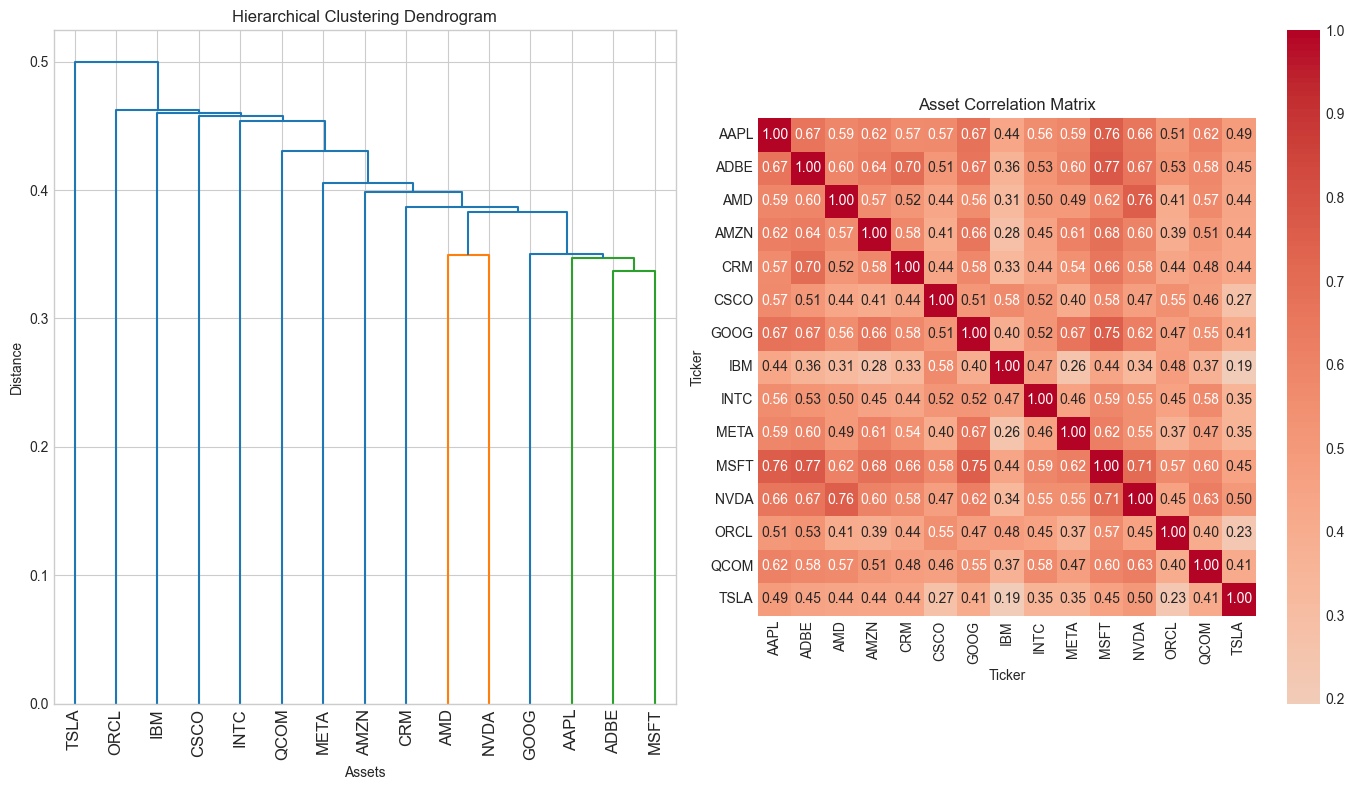

In [11]:
# Visualize HRP clustering structure
fig = plot_hrp_dendrogram(prices)
plt.show()

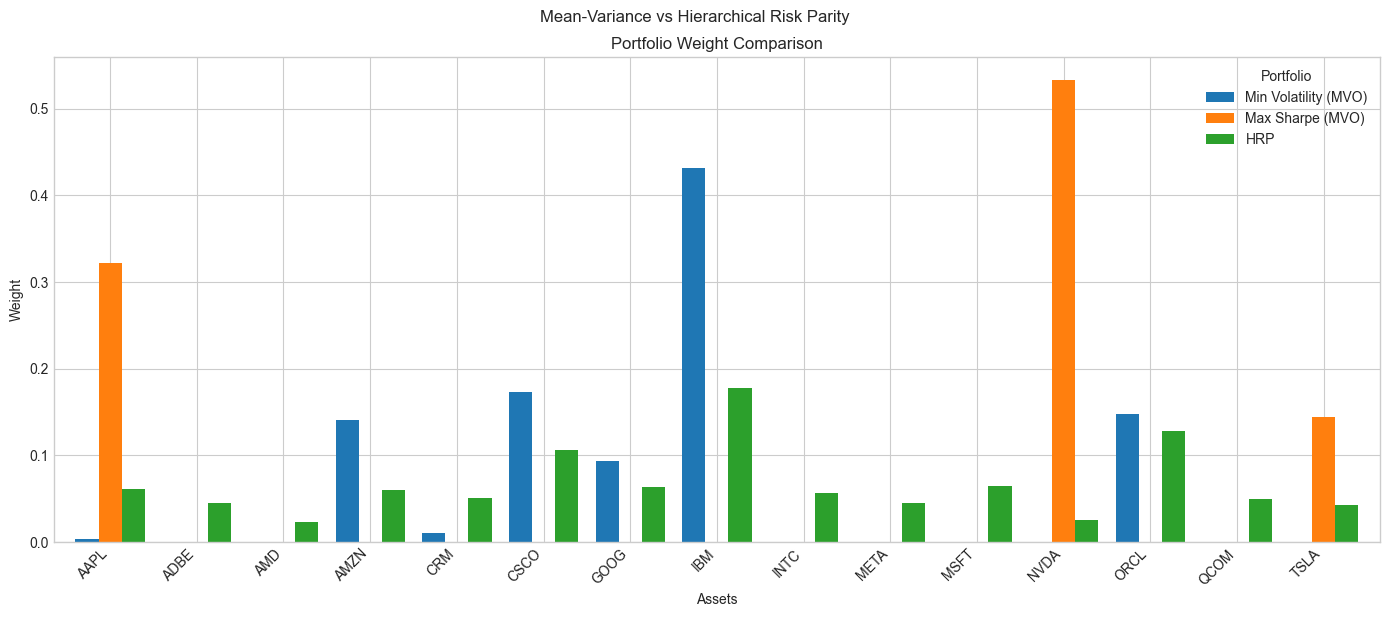

In [12]:
# Compare HRP with Mean-Variance approaches
all_portfolios = {
    'Min Volatility (MVO)': optimized_portfolios['Min Volatility'],
    'Max Sharpe (MVO)': optimized_portfolios['Max Sharpe'],
    'HRP': hrp_result
}

fig = plot_weights_comparison(all_portfolios)
plt.suptitle('Mean-Variance vs Hierarchical Risk Parity', y=1.02)
plt.show()

## 6. Backtesting and Evaluation Metrics

Now we evaluate portfolio performance using historical backtesting. This demonstrates the separation between:
- **Financial metrics**: Total return, Sharpe ratio, max drawdown, VaR
- **Mathematical toolkit metrics**: Covariance estimation quality, clustering stability

In [13]:
# Run backtests for all portfolios
backtest_results = {}
for name, portfolio in all_portfolios.items():
    backtest_results[name] = backtest_portfolio(
        weights=portfolio['weights'],
        prices=prices,
        initial_value=100000
    )

# Display performance summary
print("\nBacktest Performance Summary")
print("="*70)
metrics_summary = pd.DataFrame({
    name: {
        'Total Return (%)': result['total_return_pct'],
        'Ann. Return (%)': result['annualized_return'] * 100,
        'Ann. Volatility (%)': result['annualized_volatility'] * 100,
        'Sharpe Ratio': result['sharpe_ratio'],
        'Max Drawdown (%)': result['max_drawdown'] * 100,
        'VaR 95% (%)': result['var_95'] * 100
    }
    for name, result in backtest_results.items()
}).round(2)

display(metrics_summary.T)


Backtest Performance Summary


,Total Return (%),Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%),VaR 95% (%)
Min Volatility (MVO),113.6300,17.7300,22.3500,0.7900,-30.9100,-1.9900
Max Sharpe (MVO),1095.4600,58.2400,41.0800,1.4200,-49.7100,-3.8500
HRP,209.7300,25.8400,25.1400,1.0300,-33.7800,-2.2900


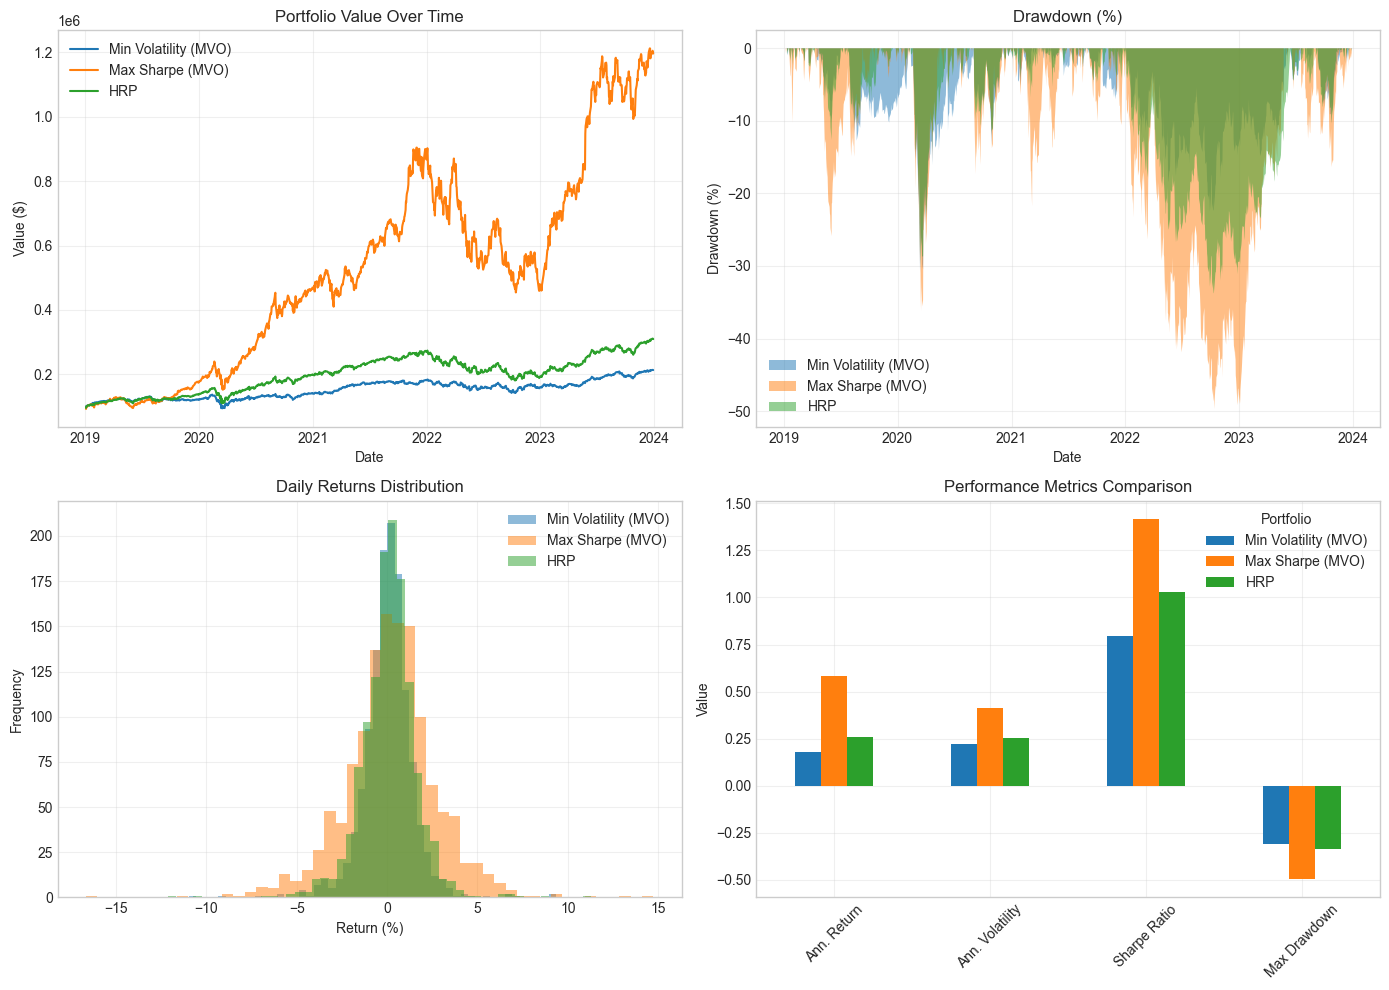

In [14]:
# Visualize backtest results
fig = plot_backtest(backtest_results)
plt.show()

## 7. Mathematical Toolkit Evaluation

Beyond financial metrics, we need to evaluate the quality of our mathematical tools:
- **Covariance estimation**: How stable is our estimate?
- **Clustering quality**: How well-separated are our clusters?

In [15]:
from pypfopt import risk_models
from portfolio_optimizer import estimate_covariance

# Compare different covariance estimation methods
cov_methods = ['sample', 'ledoit_wolf', 'exp_cov']
cov_estimates = {method: estimate_covariance(prices, method) for method in cov_methods}

# Calculate condition numbers (lower is better, indicates numerical stability)
print("Covariance Matrix Quality Metrics")
print("="*50)
for method, cov in cov_estimates.items():
    eigenvalues = np.linalg.eigvals(cov.values)
    condition_number = np.max(eigenvalues) / np.min(eigenvalues)
    print(f"\n{method}:")
    print(f"  Condition Number: {condition_number:.2f}")
    print(f"  Min Eigenvalue: {np.min(eigenvalues):.6f}")
    print(f"  Max Eigenvalue: {np.max(eigenvalues):.6f}")

Covariance Matrix Quality Metrics

sample:
  Condition Number: 77.61
  Min Eigenvalue: 0.017530
  Max Eigenvalue: 1.360471

ledoit_wolf:
  Condition Number: 70.45
  Min Eigenvalue: 0.019109
  Max Eigenvalue: 1.346237

exp_cov:
  Condition Number: 52.05
  Min Eigenvalue: 0.014107
  Max Eigenvalue: 0.734316


In [16]:
# Impact of covariance method on optimization
cov_impact = {}
for cov_method in cov_methods:
    config = PortfolioConfig(
        tickers=list(prices.columns),
        start_date=START_DATE,
        end_date=END_DATE,
        optimization_target='max_sharpe'
    )
    result = optimize_portfolio(config, prices, cov_method=cov_method)
    cov_impact[f'Max Sharpe ({cov_method})'] = result

# Compare results
print("\nImpact of Covariance Estimation Method")
print("="*50)
for name, result in cov_impact.items():
    print(f"\n{name}:")
    print(f"  Sharpe: {result['sharpe_ratio']:.3f}")
    print(f"  Volatility: {result['volatility']*100:.2f}%")


Impact of Covariance Estimation Method

Max Sharpe (sample):
  Sharpe: 1.406
  Volatility: 41.08%

Max Sharpe (ledoit_wolf):
  Sharpe: 1.411
  Volatility: 40.97%

Max Sharpe (exp_cov):
  Sharpe: 2.071
  Volatility: 18.90%


## 8. Key Takeaways

### What We Evaluated

**Financial Metrics (Backtest-based):**
- Total/Annualized Return
- Volatility (standard deviation of returns)
- Sharpe Ratio (risk-adjusted return)
- Maximum Drawdown
- Value at Risk (VaR)

**Mathematical Toolkit Metrics:**
- Covariance matrix condition number
- Eigenvalue distribution
- Clustering stability (for HRP)

### The Gap in Wealth Management

These metrics tell us how well we solved a *mathematical problem*, but they don't tell us:
- Did we understand the customer's actual needs?
- Did we correctly translate their narrative into constraints?
- Can the customer understand and trust our recommendations?

**This is where LLMs and AI agents come in** - covered in the next notebooks.

In [17]:
# Summary of all optimizations performed
print("Summary: Portfolio Optimization Results")
print("="*70)

summary_df = pd.DataFrame()
for name, result in all_portfolios.items():
    bt = backtest_results[name]
    summary_df[name] = {
        'Expected Return': f"{result['expected_return']*100:.1f}%",
        'Volatility': f"{result['volatility']*100:.1f}%",
        'Sharpe (Expected)': f"{result['sharpe_ratio']:.2f}",
        'Sharpe (Backtest)': f"{bt['sharpe_ratio']:.2f}",
        'Max Drawdown': f"{bt['max_drawdown']*100:.1f}%",
        'VaR 95%': f"{bt['var_95']*100:.2f}%"
    }

display(summary_df.T)

Summary: Portfolio Optimization Results


,Expected Return,Volatility,Sharpe (Expected),Sharpe (Backtest),Max Drawdown,VaR 95%
Min Volatility (MVO),14.4%,22.3%,0.56,0.79,-30.9%,-1.99%
Max Sharpe (MVO),59.8%,41.1%,1.41,1.42,-49.7%,-3.85%
HRP,25.8%,25.1%,1.03,1.03,-33.8%,-2.29%


---

**Next:** In Notebook 2, we'll use Large Language Models to bridge the gap between customer narratives and mathematical optimization.